In [5]:
%load_ext autoreload
%autoreload 2
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Ridge
from Preprocess import preprocess_data


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

Optimal Alpha Value: 120.67926406393289
Ridge Regression Error: 25691.525483149475
Average Error per Record in seconds: 21791.409707113453
slip_size      3843.099280
tide_deriv    -2312.147708
high_t_evt     -537.402326
form_fac        510.805402
tide_height     -11.517861
time_since       -0.003542
dtype: float64
slip_size      4132.616775
form_fac       2099.387703
time_since     1241.478298
tide_height     574.188055
tide_deriv      377.861965
high_t_evt      256.097528
dtype: float64
Ridge Regression Drivers: slip_size      3224.938960
form_fac       1156.176117
tide_height     410.303991
tide_deriv      283.019802
high_t_evt      228.031000
time_since      127.248274
dtype: float64


c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


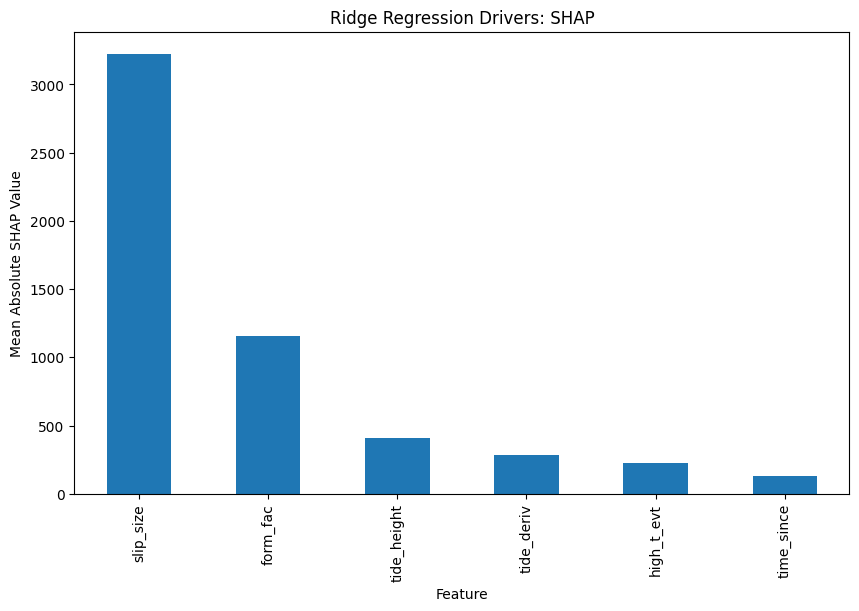

In [7]:

alphas = np.logspace(-2,8) #Testing alpha values between 10^-2 and 10^8
val_RMSE =[] # list to store the results from each alpha for comparison

# Running each alpha through the ridge regression, testing how well it does on the validation data, then storing the result in the above list for comparison
for a in alphas:
  model = Ridge(alpha=a)
  model.fit(X_train, y_train)
  y_prediction_val = model.predict(X_val)
  RMSE = root_mean_squared_error(y_val, y_prediction_val)
  val_RMSE.append(RMSE)

# Selecting the alpha that minimizes the error
optimal_alpha = alphas[np.argmin(val_RMSE)]
print("Optimal Alpha Value:", optimal_alpha)

# Combining the training and validation sets into all training for the final model
X_full_train = pd.concat([X_train, X_val])
y_full_train = pd.concat([y_train, y_val])

# Sanity check
#print(len(X_full_train) == len(y_full_train))
#print(X_full_train.shape)
#print(y_full_train.shape)

# Final ridge regression on test data
Ridge_model = Ridge(alpha=optimal_alpha)
Ridge_model.fit(X_full_train, y_full_train)
Ridge_prediction = Ridge_model.predict(X_test)
final_RMSE = root_mean_squared_error(y_test, Ridge_prediction)
RR_RMSE = final_RMSE 
print("Ridge Regression Error:", RR_RMSE)

#Error per sample in terms of seconds

absoulte_error = np.abs(Ridge_prediction - y_test)
MAE_seconds = mean_absolute_error(y_test, Ridge_prediction)
#MAE_seconds = np.mean(absoulte_error)
print("Average Error per Record in seconds:", MAE_seconds)

#Identification of Driving Parameters Based on Weights:

drivers = pd.Series(Ridge(alpha=optimal_alpha).fit(X_full_train, y_full_train).coef_, index=feature_cols)
drivers = drivers.sort_values(key=np.abs, ascending=False)
print(drivers)

#ID of Driving Parameters Based on How Greatly they Vary the Prediction
feature_std = X_full_train.std(axis=0)
contribution = feature_std * np.abs(Ridge(alpha=optimal_alpha).fit(X_full_train, y_full_train).coef_)
drivers_vari = pd.Series(contribution, index=feature_cols).sort_values(ascending=False)
print(drivers_vari)

#ID of driving parameters based on shap for consistency  

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
explainer_ridge = shap.LinearExplainer(Ridge_model, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_ridge = explainer_ridge.shap_values(X_shap) #Doing linear analysis on ridge using training data

XG_imp = pd.Series(np.abs(shap_values_ridge).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in ridge

print("Ridge Regression Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("Ridge Regression Drivers: SHAP")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()

In [8]:
data_orig[data_orig.isna().any(axis=1)]

,tide_h,tide_deriv,form_fac,time_since,slip_size,high_t_evt,start_time,tide_height
0,-81.877624,-0.268681,1.826057,NaN,-3.054164,0,2008-01-25 01:01:00,-81.877624
4564,NaN,0.109488,2.553211,1345.25,0.948091,0,2018-02-27 12:10:00,54.423922
4565,NaN,0.186609,1.841384,1560.00,0.700141,0,2018-02-28 14:10:00,60.349041
4566,NaN,0.159049,1.385693,1340.00,0.242583,0,2018-03-01 12:30:00,16.962307
4567,NaN,-0.504063,1.385693,575.00,-1.503610,0,2018-03-01 22:05:00,-58.719615
...,...,...,...,...,...,...,...,...
5145,NaN,-0.115850,5.939900,1430.00,1.089493,0,2019-11-20 17:54:00,49.657021
5146,NaN,-0.041322,2.461490,800.00,-0.047944,0,2019-11-21 07:14:00,-50.453689
5147,NaN,-0.168629,2.461490,770.00,-0.950877,0,2019-11-21 20:04:00,3.923810
5148,NaN,-0.223637,0.849641,1265.00,0.481421,0,2019-11-22 17:09:00,25.649224


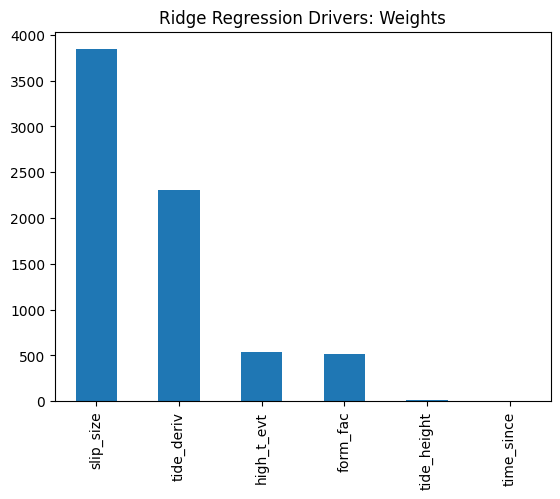

In [9]:

#Plot of drivers with weights

plt.figure()
drivers.abs().plot.bar()
plt.title("Ridge Regression Drivers: Weights")
plt.show()


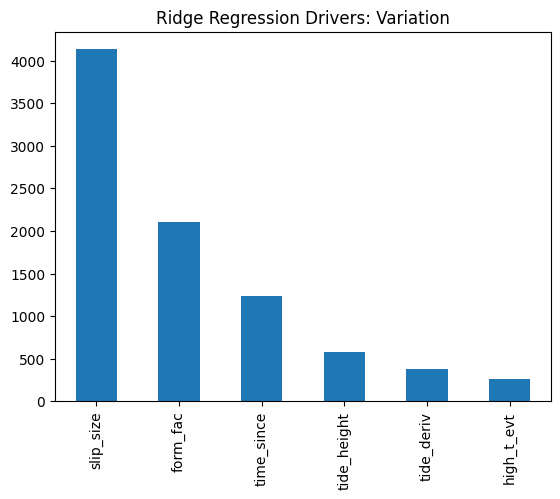

In [10]:
#Plot of drivers with varience:
plt.figure()
drivers_vari.abs().plot.bar()
plt.title("Ridge Regression Drivers: Variation")
plt.show()

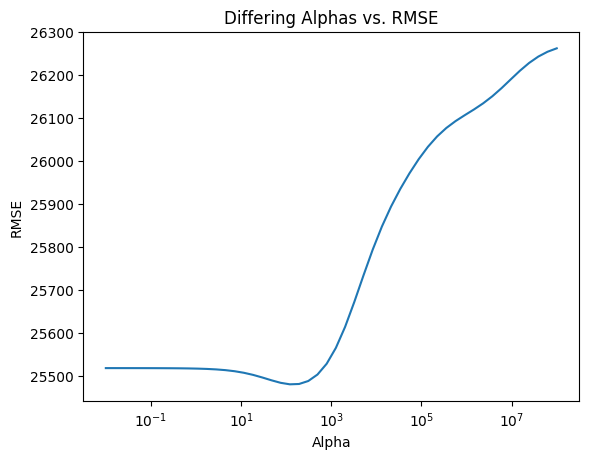

In [11]:
# Alpha values vs MAE
plt.figure()
plt.plot(alphas, val_RMSE)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('RMSE')
plt.title('Differing Alphas vs. RMSE')
plt.show()

#Multiplicative Error vs Actual Value for Ridge Regression

#Error in terms of seconds for Ridge Regression (may need to unscale and then recompute a MAE for this one)


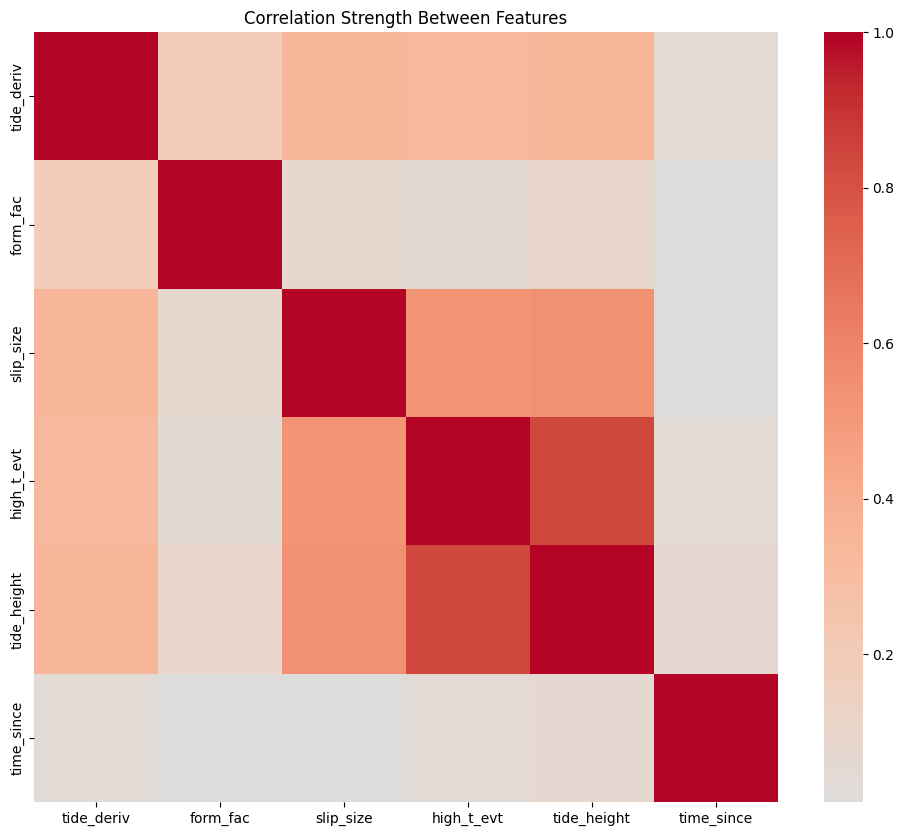

Condition Number: 2444203.9799816497


In [12]:
# What about the data set drove getting that optimal alpha value:
correlation = X_train.corr().abs() #Seeing correlation of the features
plt.figure(figsize=(12,10)) #Visualizing the feature correlation
sns.heatmap(correlation, cmap='coolwarm', center=0)
plt.title('Correlation Strength Between Features')
plt.show()
#print("Feature correlation:", correlation)

#Statistical measure of whether there are likely redundant features (checking linear independence)
condition = np.linalg.cond(X_train)
print("Condition Number:", condition)

Sample0: True = 53550.00s, Predicted = 54931.87s, Error=1381.87s
Sample1: True = 83610.00s, Predicted = 53043.40s, Error=30566.60s
Sample2: True = 93015.00s, Predicted = 58478.73s, Error=34536.27s
Sample3: True = 73710.00s, Predicted = 59901.90s, Error=13808.10s
Sample4: True = 55650.00s, Predicted = 58826.69s, Error=3176.69s
Sample5: True = 38625.00s, Predicted = 54152.38s, Error=15527.38s
Sample6: True = 73170.00s, Predicted = 52453.70s, Error=20716.30s
Sample7: True = 55140.00s, Predicted = 56808.29s, Error=1668.29s
Sample8: True = 40740.00s, Predicted = 54215.43s, Error=13475.43s
Sample9: True = 75480.00s, Predicted = 51762.54s, Error=23717.46s
Sample10: True = 83955.00s, Predicted = 56515.37s, Error=27439.63s
Sample11: True = 87045.00s, Predicted = 60052.70s, Error=26992.30s
Sample12: True = 86970.00s, Predicted = 60525.74s, Error=26444.26s
Sample13: True = 90210.00s, Predicted = 67672.94s, Error=22537.06s
Sample14: True = 30180.00s, Predicted = 62930.15s, Error=32750.15s
Sample15

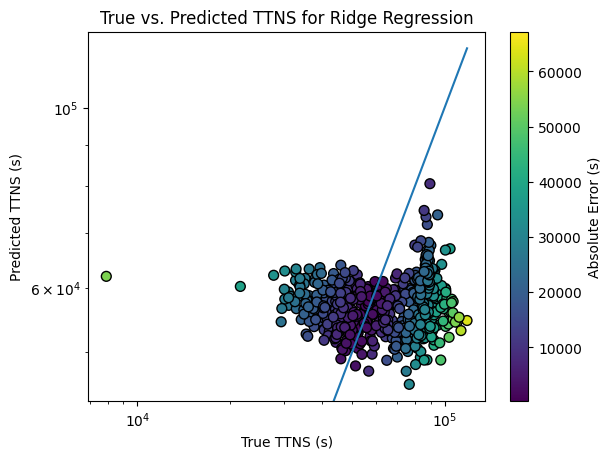

In [13]:
# Ridge Prediction Analysis:

y_test_secs = y_test #Taking it out of log scale
y_pred_secs = Ridge_prediction

absolute_error_secs = np.abs(y_pred_secs - y_test_secs)

for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, y_pred_secs, absolute_error_secs)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, y_pred_secs, c=absolute_error_secs, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Ridge Regression")
plt.xscale('log')
plt.yscale('log')
plt.show()